In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("students.csv")


In [176]:
#Task 1 — Data Exploration with Pandas
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [177]:
df.shape

(15, 9)

In [178]:
df.dtypes

,0
name,object
math,int64
science,int64
english,int64
history,int64
pe,int64
attendance_pct,int64
study_hours_per_day,float64
passed,int64


In [179]:
df.describe().loc[['mean','min','max','std']]

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093


In [180]:
df['passed'].value_counts()

,count
passed,
1,9
0,6


In [181]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df[df['passed'] == 1][subject_cols].mean()

,0
math,78.222222
science,78.555556
english,79.111111
history,73.444444
pe,86.000000


In [182]:
df[df['passed'] == 0][subject_cols].mean()


,0
math,45.166667
science,49.000000
english,46.833333
history,48.333333
pe,58.000000


In [183]:
df.loc[df[['math','science','english','history','pe']].mean(axis=1).idxmax()]

,3
name,Diana
math,95
science,98
english,91
history,89
pe,97
attendance_pct,98
study_hours_per_day,6.0
passed,1


In [184]:
#Task 2 — Data Visualization with Matplotlib
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed,avg_score
0,Alice,88,92,76,80,95,92,4.5,1,86.2
1,Bob,42,55,48,50,60,65,1.2,0,51.0
2,Charlie,75,70,80,68,88,85,3.0,1,76.2
3,Diana,95,98,91,89,97,98,6.0,1,94.0
4,Eve,38,42,50,45,55,58,0.8,0,46.0


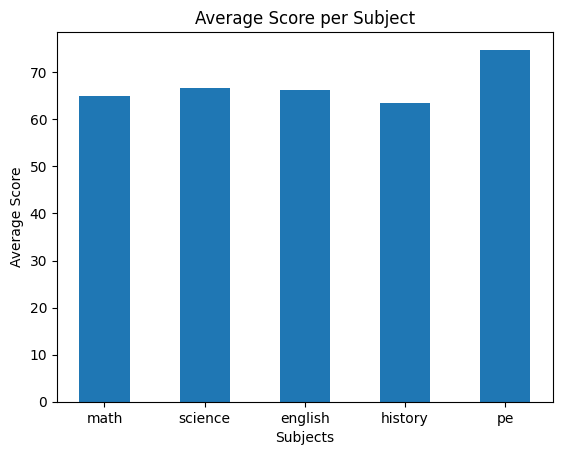

In [185]:
avg_scores = []
for subject in subject_cols:
    avg_scores.append(df[subject].mean())

plt.bar(subject_cols, avg_scores, width=0.5)
plt.title('Average Score per Subject')
plt.xlabel('Subjects')
plt.ylabel('Average Score')

plt.savefig('plot1_bar.png')
plt.show()

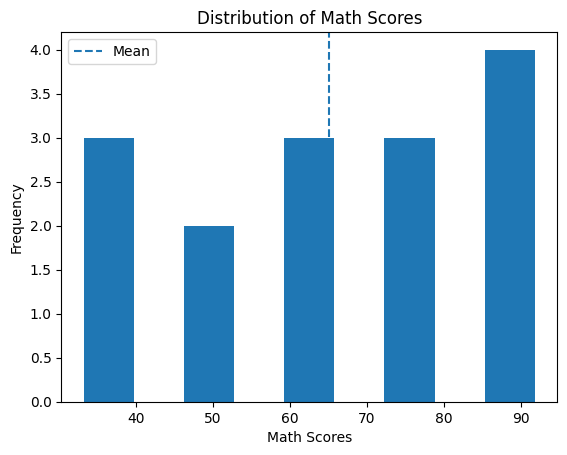

In [186]:
plt.hist(df['math'], bins=5, rwidth=0.5)

mean_value = df['math'].mean()
plt.axvline(mean_value, linestyle='dashed', label='Mean')

plt.title('Distribution of Math Scores')
plt.xlabel('Math Scores')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('plot2_hist.png')

plt.show()

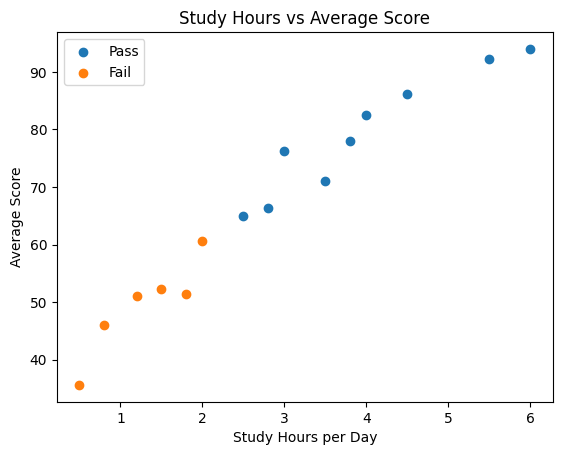

In [187]:
df['avg_score'] = df[['math','science','english','history','pe']].mean(axis=1)

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label='Pass')
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label='Fail')

plt.title('Study Hours vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')

plt.legend()

plt.savefig('plot3_scatter.png')
plt.show()

/tmp/ipykernel_2274/1307539735.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Pass', 'Fail'])


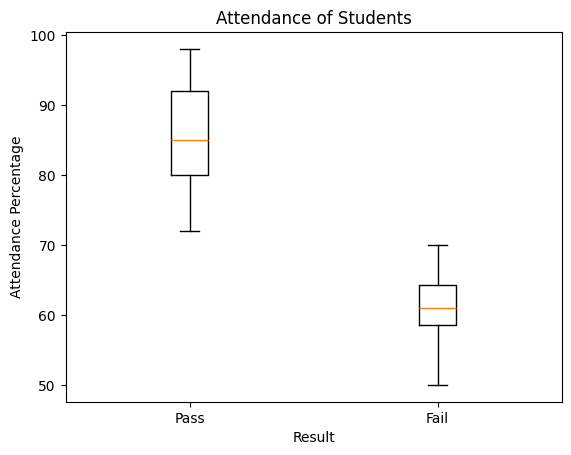

In [188]:
pass_attendance = df[df['passed'] == 1]['attendance_pct']
fail_attendance = df[df['passed'] == 0]['attendance_pct']

data = [pass_attendance, fail_attendance]

plt.boxplot(data, labels=['Pass', 'Fail'])

plt.title('Attendance of Students')
plt.xlabel('Result')
plt.ylabel('Attendance Percentage')

plt.savefig('plot4_box.png')
plt.show()

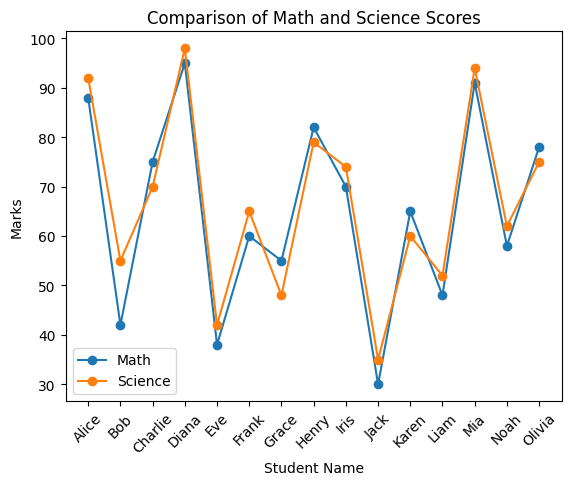

In [189]:
names = df['name']

plt.plot(names, df['math'], marker='o', label='Math')
plt.plot(names, df['science'], marker='o', label='Science')

plt.title('Comparison of Math and Science Scores')
plt.xlabel('Student Name')
plt.ylabel('Marks')

plt.xticks(rotation=45)
plt.legend()

plt.savefig('plot5_line.png')
plt.show()

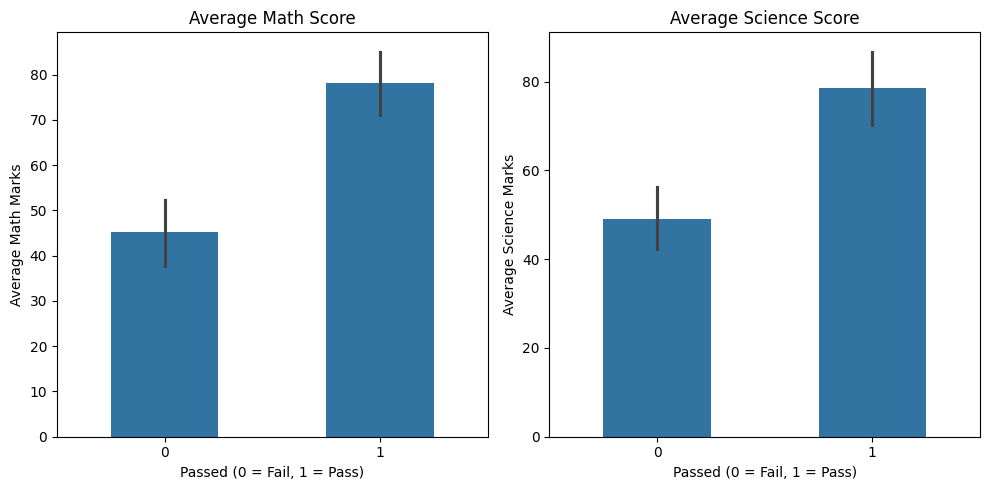

In [190]:
#Task 3 — Data Visualization with Seaborn

plt.figure(figsize=(10,5))

ax1 = plt.subplot(1, 2, 1)

sns.barplot(data=df, x='passed', y='math', ax=ax1, width=0.5)

ax1.set_title('Average Math Score')
ax1.set_xlabel('Passed (0 = Fail, 1 = Pass)')
ax1.set_ylabel('Average Math Marks')

ax2 = plt.subplot(1, 2, 2)

sns.barplot(data=df, x='passed', y='science', ax=ax2, width=0.5)

ax2.set_title('Average Science Score')
ax2.set_xlabel('Passed (0 = Fail, 1 = Pass)')
ax2.set_ylabel('Average Science Marks')


plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png')
plt.show()

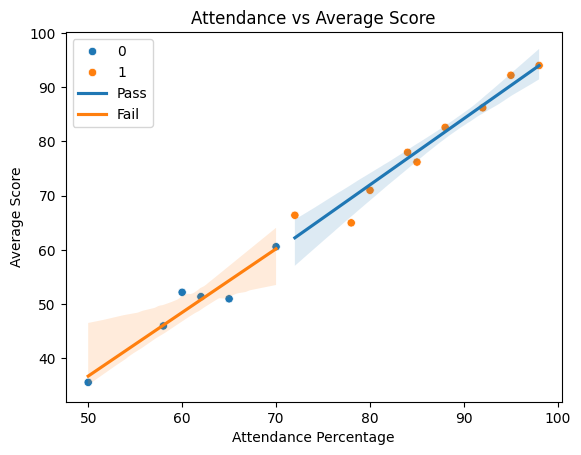

In [191]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title('Attendance vs Average Score')
plt.xlabel('Attendance Percentage')
plt.ylabel('Average Score')

plt.legend()

plt.savefig('plot7_seaborn_scatter.png')

plt.show()


#Matplotlib was easier in for bar most graphs, but scatter plot was simpler on using Seaborn. Personally, I faced a little difficulty while executing the histogram, but once understood, it was also pretty simple to use.

In [192]:
#Task 4 — Machine Learning with scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# features (exclude student_name, keep df intact)
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]

# target
y = df['passed']

# train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [193]:
# train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# training accuracy
print(model.score(X_train_scaled, y_train))

1.0


In [194]:
# predictions on test set
y_pred = model.predict(X_test_scaled)

# test accuracy
print("Test Accuracy:", model.score(X_test_scaled, y_test))

# print results for each student
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅ correct" if actual == pred else "❌ wrong"
    print(name, "| Actual:", actual, "| Predicted:", pred, "|", result)

Test Accuracy: 1.0
Jack | Actual: 0 | Predicted: 0 | ✅ correct
Liam | Actual: 0 | Predicted: 0 | ✅ correct
Alice | Actual: 1 | Predicted: 1 | ✅ correct


english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


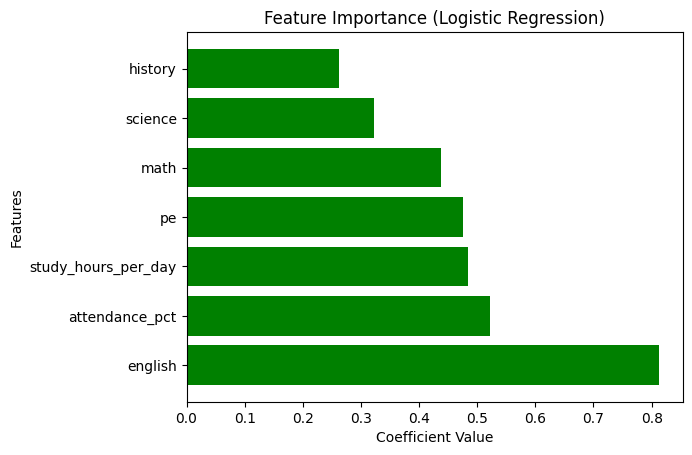

In [195]:
# get coefficients
coefficients = model.coef_[0]
features = X.columns

# pair and sort by absolute value
coef_data = list(zip(features, coefficients))
coef_data.sort(key=lambda x: abs(x[1]), reverse=True)

# print feature importance
for feature, coef in coef_data:
    print(feature, ":", coef)

# separate for plotting
features_sorted = [x[0] for x in coef_data]
coef_sorted = [x[1] for x in coef_data]

# color based on sign
colors = ['green' if c > 0 else 'red' for c in coef_sorted]

# horizontal bar plot
plt.barh(features_sorted, coef_sorted, color=colors)

plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')

plt.savefig('plot_feature_importance.png')
plt.show()

In [196]:
# new student data (same order as features)
new_student = [[55, 40, 68, 55, 40, 79, 4.2]]

# scale using existing scaler
new_student_scaled = scaler.transform(new_student)

# prediction
prediction = model.predict(new_student_scaled)[0]

# probability
probability = model.predict_proba(new_student_scaled)[0]

# print result
result = "Pass" if prediction == 1 else "Fail"

print("Prediction:", result)
print("Probability [Fail, Pass]:", probability)

Prediction: Fail
Probability [Fail, Pass]: [0.5522529 0.4477471]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
